# LeetCode #50: Pow(x, n)

https://leetcode.com/problems/powx-n/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(1)$ |
| **Recursive Fast Expo** | $O(\log n)$ | $O(\log n)$ |
| **Iterative Binary Expo** ★ | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Multiply x by itself n times. $O(n)$ — TLE for n = $2 \times 10^9$.

### Recursive Fast Exponentiation
`pow(x, n) = pow(x, n//2)^2` (multiply by x if n is odd). Clean recursion, $O(\log n)$ depth.

### Optimal: Iterative Binary Exponentiation ★
Process bits of n from LSB to MSB. Maintain a `currentPower` (starting at x, doubling each step). When the current bit is 1, multiply `result` by `currentPower`. No recursion, $O(1)$ space.

**Edge case:** `n = INT_MIN` (-2147483648) can't be negated as int32; use `long`.

**Constraints:**
* $-100.0 < x < 100.0$
* $-2^{31} \leq n \leq 2^{31} - 1$
* $n$ is an integer
* Either $x \neq 0$ or $n > 0$
* $-10^4 \leq x^n \leq 10^4$

## Solutions

### C#

In [ ]:
public class Solution {
    public double MyPow(double x, int n) {
        long N = n; // use long to handle INT_MIN safely
        if (N < 0) { x = 1.0 / x; N = -N; }
        double result = 1.0;
        while (N > 0) {
            if ((N & 1) == 1) result *= x; // bit is 1: include this power
            x *= x;                         // square for next bit
            N >>= 1;                        // shift to next bit
        }
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def myPow(self, x: float, n: int) -> float:
        if n < 0:
            x = 1.0 / x
            n = -n
        result = 1.0
        while n > 0:
            if n & 1:
                result *= x
            x *= x
            n >>= 1
        return result

### Go

In [ ]:
package main

func myPow(x float64, n int) float64 {
	if n < 0 {
		x = 1.0 / x
		n = -n
	}
	result := 1.0
	for n > 0 {
		if n&1 == 1 {
			result *= x
		}
		x *= x
		n >>= 1
	}
	return result
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn my_pow(mut x: f64, n: i32) -> f64 {
        let mut n = n as i64; // use i64 to handle i32::MIN
        if n < 0 {
            x = 1.0 / x;
            n = -n;
        }
        let mut result = 1.0f64;
        while n > 0 {
            if n & 1 == 1 {
                result *= x;
            }
            x *= x;
            n >>= 1;
        }
        result
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `x = 2.0, n = 10`

Walk through: Binary of 10 = `1010`. Process bits LSB→MSB: bit0=0 (skip), bit1=1 (result $\times$ 4), bit2=0 (skip), bit3=1 (result $\times$ 256). Result = $4 \times 256 = 1024$. Only 4 iterations instead of 10 multiplications.

**Why tricky:** Classic binary exponentiation — interviewers use it to confirm you understand the bit-processing mechanism. Result = $x^2 \times x^8$ using only the "on" bits.

### 2. Slightly Complex — Negative Exponent with Floating Point
**Input:** `x = 2.1, n = -3`

Walk through: Negative n → compute `pow(1/x, |n|)`. So `x = 1/2.1 ≈ 0.47619`, `n = 3`. Binary of 3 = `11`: both bits on → result = $0.47619 \times 0.22676 \approx 0.10798$. Equivalent to $1/2.1^3 = 1/9.261$.

**Why tricky:** Two concerns: (1) handling negative n by inverting x first, (2) floating-point precision means the result may not be exact. Interviewers check both.

### 3. Edge Case: Time Factor — n = INT_MAX ($2^{31} - 1 = 2{,}147{,}483{,}647$)
**Input:** `x = 1.00001, n = 2,147,483,647`

Walk through: Brute force needs $\approx 2 \times 10^9$ multiplications → TLE. Binary exponentiation: $\lfloor \log_2(2^{31}-1) \rfloor = 30$ iterations → instant. The core speedup: $O(\log n)$ means $\log_2(2 \times 10^9) \approx 31$ multiplications.

**Why tricky:** This is the reason binary exponentiation exists. Interviewers expect you to articulate: "brute force is $O(n)$ which is $2 \times 10^9$ operations; binary expo is $O(\log n) = 31$ operations."

### 4. Edge Case: Space Factor — Recursive vs Iterative Stack Depth
**Input:** `x = 2.0, n = 2,147,483,647`

Walk through: Recursive approach: 31 stack frames ($O(\log n)$ space). Iterative approach: 0 stack frames ($O(1)$ space). While 31 frames is manageable, the iterative version is strictly better. Result overflows double to $+\infty$.

**Why tricky:** Interviewers appreciate candidates who mention the space distinction. Both are $O(\log n)$ time, but iterative is $O(1)$ space. It shows depth beyond "both are log n."

### 5. Almost-Impossible but Plausible — n = INT_MIN ($-2^{31} = -2{,}147{,}483{,}648$)
**Input:** `x = 2.0, n = -2,147,483,648`

Walk through: `|INT_MIN| = 2,147,483,648` overflows int32 (max is $2{,}147{,}483{,}647$). Negating $-2^{31}$ as int32 wraps back to $-2^{31}$! Fix: cast to `long` BEFORE negating. Then compute `pow(0.5, 2147483648L)` $\approx 0$.

**Why tricky:** The single most common bug in Pow(x,n). Two's complement asymmetry: $|INT\_MIN| > INT\_MAX$ by 1. Interviewers specifically test this — always cast to `long` before negating.

---

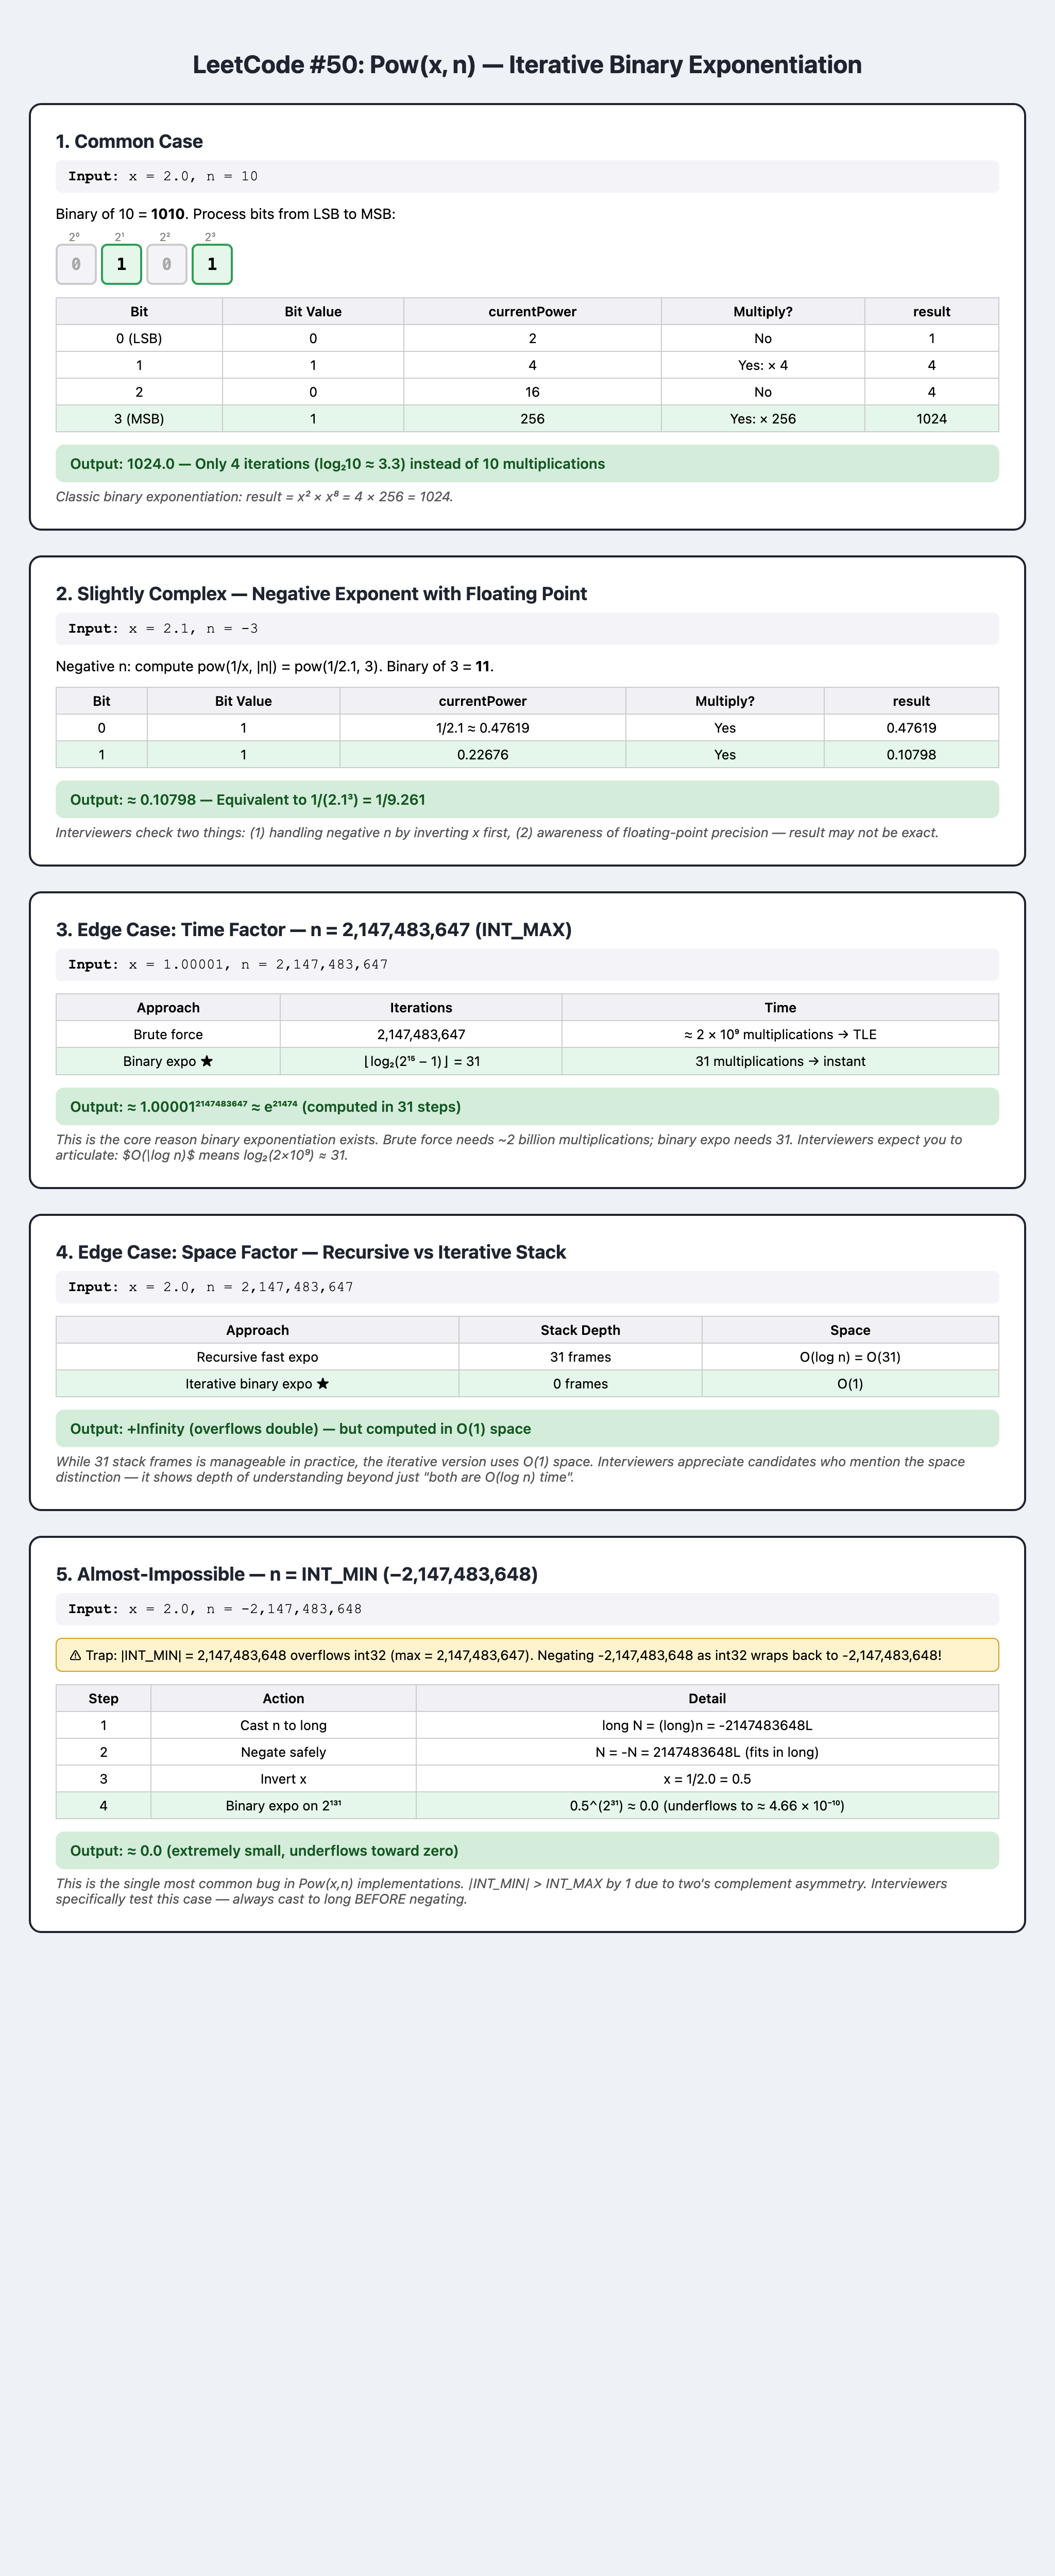